In [ ]:
פוטנציאל חור שחור

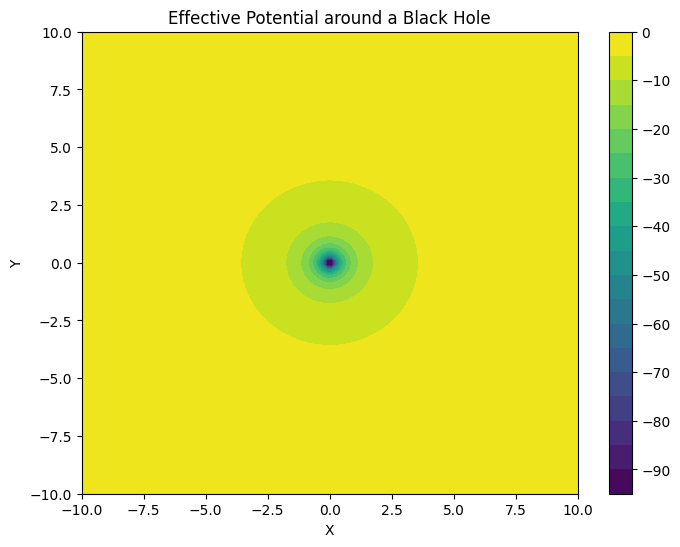

In [ ]:
import numpy as np
from scipy import sparse
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh  # Import sparse eigenvalue solver
from scipy.constants import G, c, pi
from scipy.integrate import solve_bvp

# Parameters
N = 100  # Use a smaller grid size for memory efficiency
X, Y = np.mgrid[-2:2:N*1j, -2:2:N*1j]

def potential_blackhole(N, X, Y, M=50.0, epsilon=1e-2):
    """
    Black-hole–like Newtonian potential: V(r) = -M / (r+epsilon)
    No boundary => entire domain uses this potential.
    """

    # Define constants (in SI units)
    G = 6.67430e-11  # Gravitational constant, m^3 kg^-1 s^-2
    c = 3.0e8           # Speed of light, m/s
    epsilon = 1e-2  # Small cutoff to avoid singularity at r = 0
    # Define physical parameters
    M = 5.972e24  # Mass of black hole (e.g., Earth mass for demonstration), kg
    m = 9.10938356e-15  # Mass of particle (electron), kg
    L = 1.0e-34  # Angular momentum, kg m^2 / s (example value)

    # Define the effective potential
    def V_eff(r, G=G, M=M, m=m, L=L, c=c):
        return ((-G * M * m / (r+epsilon)) + (L**2) / (2 * m * (r+epsilon)**2) - (G * M * L**2) / (c**2 * m * (r+epsilon)**3))

    # Define range of r (from some minimum to a maximum value)
    r = np.sqrt(X**2 + Y**2)
    # Calculate V_eff(r)
    V = V_eff(r)

    # Create a meshgrid for plotting
    x = np.linspace(-10, 10, N)
    y = np.linspace(-10, 10, N)
    X, Y = np.meshgrid(x, y)

    # Plot the effective potential
    plt.figure(figsize=(8, 6))
    plt.contourf(X, Y, V, levels=20, cmap='viridis')
    plt.colorbar()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Effective Potential around a Black Hole')
    plt.show()


potential_blackhole(N, X, Y)

ניתוח רמות אנרגיה ויצירת ההיסטוגרמה(כולל השוואה למודלים אחרים)

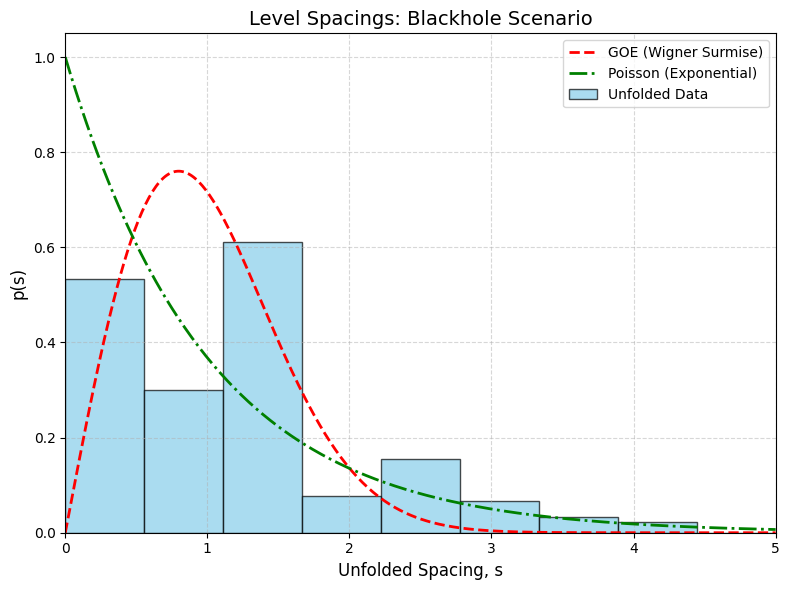

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import eigsh
from scipy.interpolate import UnivariateSpline

##############################################################################
#                          1. USER CHOICE: SCENARIO                          #
##############################################################################
scenario = 'blackhole'     # <--- set to 'stadium' or 'blackhole'

##############################################################################
#                            2. SPATIAL GRID                                 #
##############################################################################
N = 400  # Grid size (increase if you have enough memory)
x_min, x_max = -2.0, 2.0
X_vals = np.linspace(x_min, x_max, N)
Y_vals = np.linspace(x_min, x_max, N)
dX = (x_max - x_min)/(N-1)
X, Y = np.meshgrid(X_vals, Y_vals, indexing='xy')

##############################################################################
#                         3. DEFINE POTENTIAL FUNCTIONS                      #
##############################################################################

def create_stadium_mask(X, Y, a, r):
    """
    Returns a boolean mask indicating points *outside* the stadium.
    Stadium = rectangle of length 'a' plus two semicircles of radius 'r'.
    We interpret True => "outside" => infinite potential.
    """
    mask_rect = (np.abs(X) < a/2) & (np.abs(Y) < r)
    mask_left_circle = ((X + a/2)**2 + Y**2) < r*r
    mask_right_circle = ((X - a/2)**2 + Y**2) < r*r
    inside_stadium = mask_rect | mask_left_circle | mask_right_circle
    return ~inside_stadium  # invert => True means outside


def potential_stadium(N, X, Y, V0=1e8):
    """
    Hard-wall stadium:
      - 0 potential inside
      - large (V0) potential outside
    """
    a = 1.0
    r = 0.5
    mask_outside = create_stadium_mask(X, Y, a, r)
    V = np.zeros((N, N), dtype=float)
    V[mask_outside] = V0
    return V


def potential_blackhole(N, X, Y, M=50.0, epsilon=1e-2):
    """
    Black-hole–like Newtonian potential: V(r) = -M / (r+epsilon)
    No boundary => entire domain uses this potential.
    """

    # Define constants (in SI units)
    G = 6.67430e-11          # Gravitational constant, m^3 kg^-1 s^-2
    c = 3.0e8                # Speed of light, m/s
    epsilon = 1e-2  # Small cutoff to avoid singularity at r = 0
    # Define physical parameters
    M = 5.972e24             # Mass of black hole (e.g., Earth mass for demonstration), kg
    m = 9.10938356e-15      # Mass of particle (electron), kg
    L = 1.0e-34              # Angular momentum, kg m^2 / s (example value)

    # Define the effective potential
    def V_eff(r, G=G, M=M, m=m, L=L, c=c):
        return ((-G * M * m / (r+epsilon)) + (L**2) / (2 * m * (r+epsilon)**2) - (G * M * L**2) / (c**2 * m * (r+epsilon)**3))

    # Define range of r (from some minimum to a maximum value)
    r = np.sqrt(X**2 + Y**2)
    # Calculate V_eff(r)
    V = V_eff(r)
    return V


##############################################################################
#                     4. CHOOSE SCENARIO AND BUILD POTENTIAL                 #
##############################################################################

if scenario == 'stadium':
    V = potential_stadium(N, X, Y, V0=1e8)
elif scenario == 'blackhole':
    V = potential_blackhole(N, X, Y, M=50.0, epsilon=1e-2)
else:
    raise ValueError("Invalid scenario. Choose 'stadium' or 'blackhole'.")

##############################################################################
#                       5. CONSTRUCT THE HAMILTONIAN                         #
##############################################################################

# --- Discrete 1D Laplacian of size N ---
#    (We place -2 on the diagonal and +1 on off-diagonals.)
diag = np.ones(N)
diags = np.array([diag, -2.0*diag, diag])
D = sparse.diags(diags, offsets=[-1,0,1], shape=(N, N))

# --- 2D Laplacian: T = -1/2 (∂²/∂x² + ∂²/∂y²)
lap2D = sparse.kron(D, sparse.eye(N)) + sparse.kron(sparse.eye(N), D)
T = -0.5 * lap2D  # factor of -1/2

# --- Potential matrix (diagonal in position basis) ---
U = sparse.diags(V.ravel(), 0)

# --- Full Hamiltonian ---
H = (T + U).tocsr()

##############################################################################
#               6. PARTIAL DIAGONALIZATION  (SMALLEST EIGENVALUES)           #
##############################################################################

num_eigs = 200  # number of eigenvalues to compute
# 'SM' => find eigenvalues with smallest magnitude.
#   - If your potential is strongly negative, you might need 'SA' (smallest algebraic).
which_mode = 'SM' if scenario == 'stadium' else 'SA'

e_vals, e_vecs = eigsh(H, k=num_eigs, which=which_mode)
e_vals = np.sort(e_vals)

# Optionally discard a few of the very lowest states
discard = 10
if len(e_vals) > discard:
    e_vals = e_vals[discard:]

##############################################################################
#                         7. UNFOLD THE SPECTRUM                             #
##############################################################################
def unfold_spectrum(e):
    """
    Given sorted eigenvalues e, fit a smooth counting function i(e) and
    produce the *unfolded* spacings.
    """
    n = len(e)
    i_vals = np.arange(1, n+1, dtype=float)  # 1..n

    # Fit i(e) using a univariate spline:
    # Adjust 's' for smoothing depending on how wiggly or smooth you want it.
    spline = UnivariateSpline(e, i_vals, s=0.5*n)
    e_tilde = spline(e)          # "unfolded" energies
    s_unfolded = np.diff(e_tilde)  # nearest-neighbor spacings
    return s_unfolded

s_unfolded = unfold_spectrum(e_vals)
# Remove any zero or negative values (shouldn't exist if e_vals are strictly ascending)
s_unfolded = s_unfolded[s_unfolded > 0]

##############################################################################
#         8. BUILD HISTOGRAM & COMPARE TO GOE (WIGNER) VS. POISSON           #
##############################################################################

# Wigner Surmise (GOE)
def p_GOE(s):
    return (np.pi / 2) * s * np.exp(-np.pi * s**2 / 4)

# Poisson (exponential)
def p_exp(s):
    return np.exp(-s)

# We'll look at s in [0, s_max] for plotting
s_max = 5.0
s_plot = np.linspace(0, s_max, 400)
p_goe = p_GOE(s_plot)
p_poi = p_exp(s_plot)

# Filter data for [0, s_max]
data_filtered = s_unfolded[(s_unfolded >= 0) & (s_unfolded <= s_max)]

# Freedman–Diaconis for bin width
if len(data_filtered) < 2:
    print("Not enough data to build a meaningful histogram.")
    bins = 10
    hist_vals = None
    bin_edges = None
else:
    IQR = np.percentile(data_filtered, 75) - np.percentile(data_filtered, 25)
    N_data = len(data_filtered)
    bin_w = max(2 * IQR / (N_data**(1/3)), 0.05)
    num_bins = int((s_max - 0) / bin_w)
    num_bins = max(num_bins, 10)  # at least 10 bins
    bin_edges = np.linspace(0, s_max, num_bins)
    counts, edges = np.histogram(data_filtered, bins=bin_edges, density=False)
    widths = np.diff(edges)
    area = np.sum(counts * widths)
    hist_vals = counts / area

##############################################################################
#                            9. PLOT THE RESULTS                             #
##############################################################################
plt.figure(figsize=(8,6))
plt.title(f"Level Spacings: {scenario.capitalize()} Scenario", fontsize=14)

if hist_vals is not None:
    plt.bar(edges[:-1], hist_vals, width=widths, align='edge',
            color='skyblue', edgecolor='k', alpha=0.7, label="Unfolded Data")

plt.plot(s_plot, p_goe, 'r--', lw=2, label="GOE (Wigner Surmise)")
plt.plot(s_plot, p_poi, 'g-.', lw=2, label="Poisson (Exponential)")

plt.xlabel("Unfolded Spacing, s", fontsize=12)
plt.ylabel("p(s)", fontsize=12)
plt.xlim(0, s_max)
plt.grid(ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

פוטנציאל חור שחור תלוי בזמן בסטדיום

In [ ]:



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Video, display
from tqdm.notebook import tqdm

# Parameters
L = 10.0        # Size of the box
N = 200         # Number of grid points per dimension
T = 30.0         # Total time
dt = 0.01      # Time step (smaller step for stability)
sigma = 0.5     # Width of the initial wave packet
x0, y0 = 0, 0   # Initial position of the wave packet
kx0, ky0 = 5, 3 # Initial momentum of the wave packet

# Spatial grid
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0]
dy = y[1] - y[0]

# Momentum grid
kx = np.fft.fftfreq(N, d=dx) * 2 * np.pi
ky = np.fft.fftfreq(N, d=dy) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2

# Initial wave packet
psi0 = np.exp(-(X-x0)**2/(2*sigma**2) - (Y-y0)**2/(2*sigma**2)) * np.exp(1j*(kx0*X + ky0*Y))
psi0 /= np.sqrt(np.sum(np.abs(psi0)**2) * dx * dy)  # Normalize

# Set the minimum and maximum values for the color scale
vmin, vmax = -5, 0  # Adjust these values as needed

# Bunimovich stadium parameters
a = 6.0  # Length of the rectangle part
r = 3.0  # Radius of the semicircles

# Animation setup
fig, ax = plt.subplots()
extent = [-L, L, -L, L]
im = ax.imshow(np.log10(np.abs(psi0)**2 + 1e-10), extent=extent, origin='lower', cmap='inferno', vmin=vmin, vmax=vmax, animated=True)
ax.set_xlabel('x')
ax.set_ylabel('y')

# Add the color bar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('log10(|ψ|^2)')

# Function to create the mask for the Bunimovich stadium
def create_bunimovich_mask(X, Y, a, r):
    mask = np.logical_or(
        np.logical_and(np.abs(X) < a/2, np.abs(Y) < a/2),
        np.logical_or(
            np.sqrt((X + a/2)**2 + Y**2) < r,
            np.sqrt((X - a/2)**2 + Y**2) < r
        )
    )
    mask = np.invert(mask)
    return mask

# Create and plot the mask boundaries
mask = create_bunimovich_mask(X, Y, a, r)
ax.contour(X, Y, mask, levels=[0.5], colors='cyan')

# Function to apply Dirichlet boundary conditions outside the Bunimovich stadium
def apply_bunimovich_bc(psi, X, Y, a, r):
    mask = create_bunimovich_mask(X, Y, a, r)
    psi[mask] = 0
    return psi

# Define the 1/r potential
epsilon = 0.1  # Small cutoff to avoid singularity
V = 1.0 / np.sqrt(X**2 + Y**2 + epsilon**2)

# Time evolution function using Split-Step Fourier method
def evolve(psi, dt, K2, V, steps):
    expK = np.exp(-1j * K2 * dt / 2)
    for step in tqdm(range(steps), desc="Evolving wave packet"):
        psi = np.fft.ifft2(expK * np.fft.fft2(psi))
        psi *= np.exp(-1j * V * dt)
        psi = apply_bunimovich_bc(psi, X, Y, a, r)  # Apply Bunimovich stadium boundary conditions
        psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx * dy)  # Normalize
        yield psi

# Update function for animation
def update(frame, data_gen):
    global psi0
    try:
        psi0 = next(data_gen)
    except StopIteration:
        print("Generator exhausted")
    im.set_array(np.log10(np.abs(psi0)**2 + 1e-10))  # Use logarithmic scale
    return [im]

# Number of steps
steps = int(T / dt)

# Create animation
data_gen = evolve(psi0, dt, K2, V, steps)
ani = animation.FuncAnimation(fig, update, frames=steps, fargs=(data_gen,), blit=True)

# Save animation as MP4
ani.save('wave_packet_evolution.mp4', writer='ffmpeg', fps=30)

# Close the plot to prevent the display of the last frame
plt.close(fig)

# Display the saved video
display(Video('wave_packet_evolution.mp4', embed=True))

Evolving wave packet:   0%|          | 0/3000 [00:00<?, ?it/s]

Generator exhausted
Generator exhausted
Generator exhausted
